# 06 -- Final Evaluation + Persistence

Out-of-fold predictions over GroupKFold give an honest, leakage-free report on
every window. The chosen pipeline is then refit on all data and saved for the
Streamlit app. Metrics: accuracy, balanced accuracy, per-class F1/recall,
confusion matrix, ROC (OvR), PR + calibration curves, and 3 independent
feature-importance views.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
%matplotlib inline
import pdm_common as P

import json, warnings, numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, balanced_accuracy_score,
                             roc_curve, auc, precision_recall_curve)
from sklearn.calibration import calibration_curve
warnings.filterwarnings("ignore")

feat = pd.read_parquet(P.ART_DIR / "features.parquet")
feat_cols = [c for c in feat.columns if c not in ("run_id", "label", "t_start")]
X = feat[feat_cols].to_numpy()
le = LabelEncoder(); y = le.fit_transform(feat["label"]); classes = le.classes_
groups = feat["run_id"].to_numpy()
best = json.loads((P.ART_DIR / "best_model.json").read_text())["best"]
K = min(20, len(feat_cols))
model = P.build_feature_models(K)[best]
cv = GroupKFold(n_splits=min(3, feat["run_id"].nunique()))
print(f"Final model: {best}  | {X.shape[0]} windows, {len(feat_cols)} features")

Final model: ExtraTrees  | 267 windows, 51 features


In [2]:
oof = np.empty_like(y)
proba = np.zeros((len(y), len(classes)))
for tr, te in cv.split(X, y, groups):
    m = clone(model).fit(X[tr], y[tr])
    oof[te] = m.predict(X[te])
    p = m.predict_proba(X[te])
    for j, cls in enumerate(m.classes_):
        proba[te, cls] = p[:, j]
print(f"Balanced accuracy (OOF): {balanced_accuracy_score(y, oof):.3f}")
print(classification_report(y, oof, target_names=classes, zero_division=0))

Balanced accuracy (OOF): 0.508
                  precision    recall  f1-score   support

   FlexibleShaft       0.00      0.00      0.00        37
  GeneratorFault       0.81      0.57      0.67        82
         Healthy       0.00      0.00      0.00         9
         Leakage       1.00      1.00      1.00        43
PumpDisplacement       0.68      0.97      0.80        96

        accuracy                           0.69       267
       macro avg       0.50      0.51      0.49       267
    weighted avg       0.65      0.69      0.65       267



## Confusion matrix

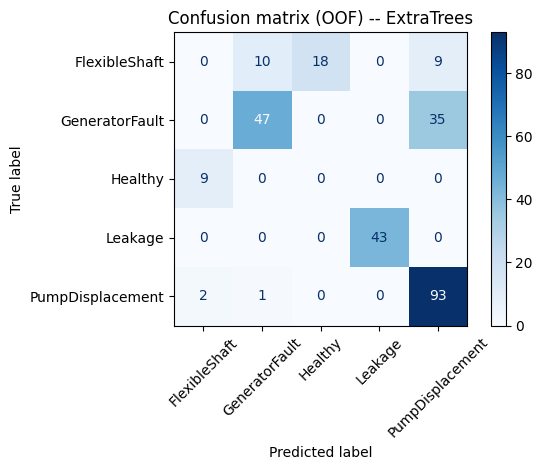

NOTE: single-run classes ['Healthy'] are never in both train and test of a fold -> their OOF scores are the honest worst case (unseen-run generalisation).


In [3]:
cm = confusion_matrix(y, oof)
ConfusionMatrixDisplay(cm, display_labels=classes).plot(xticks_rotation=45, cmap="Blues")
plt.title(f"Confusion matrix (OOF) -- {best}"); plt.tight_layout(); plt.show()
_single = sorted(feat.groupby("label")["run_id"].nunique().pipe(lambda s: s[s < 2]).index)
if _single:
    print(f"NOTE: single-run classes {_single} are never in both train and test of a "
          "fold -> their OOF scores are the honest worst case (unseen-run generalisation).")

## ROC (one-vs-rest) + Precision-Recall

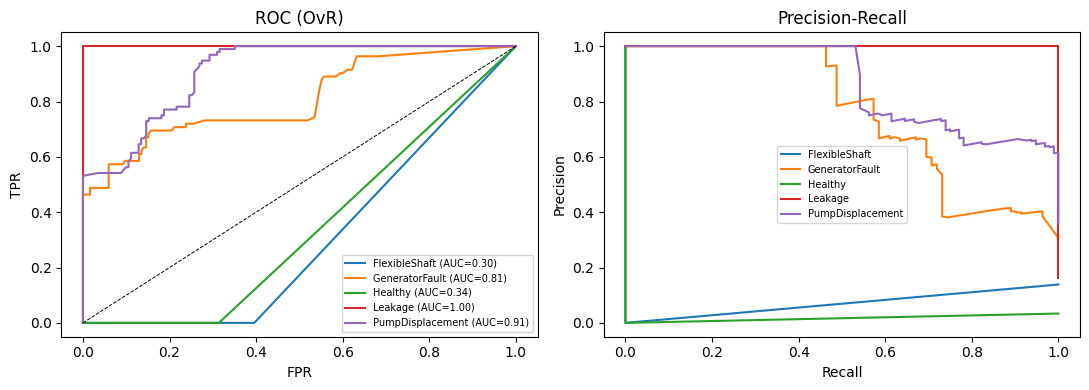

In [4]:
Yb = label_binarize(y, classes=range(len(classes)))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i, c in enumerate(classes):
    if Yb[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(Yb[:, i], proba[:, i])
    ax[0].plot(fpr, tpr, label=f"{c} (AUC={auc(fpr, tpr):.2f})")
    pr, rc, _ = precision_recall_curve(Yb[:, i], proba[:, i])
    ax[1].plot(rc, pr, label=c)
ax[0].plot([0, 1], [0, 1], "k--", lw=0.7); ax[0].set(title="ROC (OvR)", xlabel="FPR", ylabel="TPR")
ax[1].set(title="Precision-Recall", xlabel="Recall", ylabel="Precision")
ax[0].legend(fontsize=7); ax[1].legend(fontsize=7); plt.tight_layout(); plt.show()

## Confidence calibration

The app shows a confidence number, so it must be meaningful.

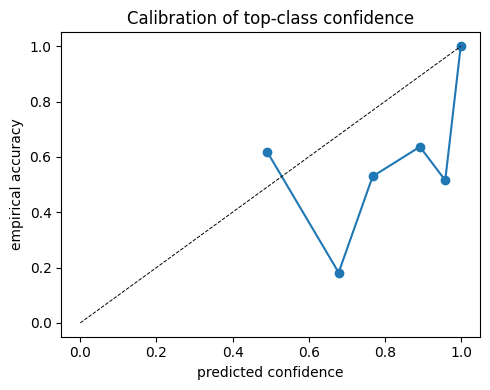

In [5]:
conf = proba.max(1); correct = (oof == y).astype(int)
fig, axc = plt.subplots(figsize=(5, 4))
frac, mean_pred = calibration_curve(correct, conf, n_bins=8, strategy="quantile")
axc.plot(mean_pred, frac, "o-"); axc.plot([0, 1], [0, 1], "k--", lw=0.7)
axc.set(title="Calibration of top-class confidence", xlabel="predicted confidence",
        ylabel="empirical accuracy"); plt.tight_layout(); plt.show()

## Per-class feature distribution stats

In [6]:
stat = feat.groupby("label")[feat_cols].agg(["mean", "median", "skew", lambda s: s.kurt()])
stat.columns = [f"{a}_{b if b else 'kurt'}" for a, b in stat.columns]
stat.to_csv(P.ART_DIR / "per_class_feature_stats.csv")
key = [c for c in ["pressure_cov", "vdc_dmean", "power_cov", "corr_vdc_i"] if c in feat_cols]
for k in key:
    cols = [c for c in [f"{k}_mean", f"{k}_median", f"{k}_skew", f"{k}_<lambda_0>"] if c in stat.columns]
    display(stat[cols].round(3))

,pressure_cov_mean,pressure_cov_median,pressure_cov_skew,pressure_cov_<lambda_0>
label,,,,
FlexibleShaft,0.040,0.033,1.641,2.709
GeneratorFault,0.052,0.025,3.934,16.552
Healthy,0.000,0.000,0.000,0.000
Leakage,0.013,0.005,3.054,10.124
PumpDisplacement,0.047,0.010,4.210,20.608


,vdc_dmean_mean,vdc_dmean_median,vdc_dmean_skew,vdc_dmean_<lambda_0>
label,,,,
FlexibleShaft,-0.000,0.000,-0.332,-1.561
GeneratorFault,-0.048,-0.056,0.725,0.180
Healthy,0.030,0.029,0.453,0.030
Leakage,-1.645,-1.027,-0.713,-1.126
PumpDisplacement,-0.022,-0.021,-0.473,2.196


,power_cov_mean,power_cov_median,power_cov_skew,power_cov_<lambda_0>
label,,,,
FlexibleShaft,0.224,0.278,0.183,-1.729
GeneratorFault,0.309,0.308,0.238,-1.328
Healthy,0.085,0.085,0.677,1.070
Leakage,0.003,0.002,2.555,8.300
PumpDisplacement,0.362,0.371,-2.394,6.329


,corr_vdc_i_mean,corr_vdc_i_median,corr_vdc_i_skew,corr_vdc_i_<lambda_0>
label,,,,
FlexibleShaft,1.000,1.0,-1.877,0.000
GeneratorFault,1.000,1.0,-1.056,0.000
Healthy,1.000,1.0,-1.029,0.000
Leakage,0.807,1.0,-1.530,0.425
PumpDisplacement,1.000,1.0,-1.351,0.000


## Feature importance -- 3 independent views (built-in, permutation, SHAP if available)

In [7]:
model.fit(X, y)
clf = model.named_steps["clf"]
inner = getattr(clf, "model_", clf)
sup = model.named_steps["sel"].get_support()
sel_names = np.array(feat_cols)[sup]

from sklearn.inspection import permutation_importance
imp = pd.DataFrame({"feature": feat_cols})
if hasattr(inner, "feature_importances_"):
    bi = pd.Series(0.0, index=feat_cols); bi[sel_names] = inner.feature_importances_
    imp["builtin"] = bi.values
try:
    pi = permutation_importance(model, X, y, n_repeats=10, random_state=0, n_jobs=-1)
    imp["perm_mean"], imp["perm_std"] = pi.importances_mean, pi.importances_std
except Exception as e:
    print(f"Permutation importance skipped ({type(e).__name__}).")

try:
    import shap
    Xs = model[:-1].transform(X)
    sv = shap.TreeExplainer(inner).shap_values(Xs)
    shap.summary_plot(sv, Xs, feature_names=sel_names, plot_type="bar", show=True)
    arr = np.array(sv)
    sh = np.abs(arr).mean(axis=tuple(range(arr.ndim - 1)))
    ss = pd.Series(0.0, index=feat_cols); ss[sel_names] = sh
    imp["shap_mean_abs"] = ss.values
except Exception as e:
    print(f"SHAP skipped ({type(e).__name__}); built-in + permutation importance kept.")

rank_col = "shap_mean_abs" if "shap_mean_abs" in imp.columns else \
           ("perm_mean" if "perm_mean" in imp.columns else "builtin")
imp = imp.sort_values(rank_col, ascending=False)
imp.to_csv(P.ART_DIR / "feature_importance.csv", index=False)
display(imp.head(12).round(4))

SHAP skipped (ModuleNotFoundError); built-in + permutation importance kept.


,feature,builtin,perm_mean,perm_std
0,pressure_cov,0.0000,0.0,0.0
38,vac_ripple,0.0000,0.0,0.0
28,vdc_kurt,0.0000,0.0,0.0
29,vdc_zcr,0.0319,0.0,0.0
30,vdc_slope,0.0000,0.0,0.0
31,vdc_speccen,0.0424,0.0,0.0
32,vdc_speclow,0.0000,0.0,0.0
33,vdc_dmean,0.0317,0.0,0.0
34,vdc_dstd,0.0352,0.0,0.0
35,vdc_drms,0.0336,0.0,0.0


## Persist final model

In [8]:
common_trained = json.loads((P.ART_DIR / "common_signals.json").read_text())
joblib.dump({"model": model, "classes": list(classes)}, P.ART_DIR / "model.joblib")
(P.ART_DIR / "meta.json").write_text(json.dumps({
    "best_model": best, "feature_cols": feat_cols, "common_signals": common_trained,
    "window_sec": P.WINDOW_SEC, "fs": P.FS, "fault_t": P.FAULT_T,
    "baseline_win": P.BASELINE_WIN, "classes": list(classes),
    "single_run_classes": _single}, indent=2))
print(f"Saved model.joblib + meta.json. Classes: {list(classes)}")

Saved model.joblib + meta.json. Classes: ['FlexibleShaft', 'GeneratorFault', 'Healthy', 'Leakage', 'PumpDisplacement']
